# 9. 真正的 LLM：MiniMind 完整架构逐行拆解

这一讲把前 8 讲的所有零件装成**一个真正能运行的 LLM**（LLaMA 风格 Decoder-only）。
我们**不跑** 1 亿参数的成品（太慢），而是用与 `model/model_minimind.py` **完全相同的结构**、
缩小 100 倍的配置，手搓一个能"训练 + 生成"的小模型，再逐行对照源码看懂每个模块。

> 学习路径：先看本讲架构总览 → 再逐个模块看"源码行号 + 我的简化实现 + 张量形状"→ 最后验证生成。

| | MiniMind 真实配置 | 本讲小配置 |
|---|---|---|
| hidden_size 隐藏维 | 768 | **8** |
| num_hidden_layers 层数 | 8 | **2** |
| num_attention_heads Q 头 | 8 | **4** |
| num_key_value_heads KV 头 | 4 (GQA) | **2** (GQA) |
| head_dim 每头维 | 96 | **2** |
| intermediate_size FFN 中间维 | 2432 | **16** |
| vocab_size 词表 | 6400 | **64** |
| max_position_embeddings | 32768 | 64 |
| rms_norm_eps | 1e-6 | 1e-6 |
| rope_theta | 1e6 | 64 |
| hidden_act | silu (SwiGLU) | silu |
| tie_word_embeddings | True | True |


## 导入 + 小配置 + 架构总览

MiniMind 前向数据流（对照 `MiniMindModel.forward`，源码 `model/model_minimind.py` 第 201-237 行）：

```
input_ids [B,T]
  → Embedding [B,T,8]          （词嵌入）
  → 2 × MiniMindBlock：
       RMSNorm → GQA Attention(RoPE+KV cache) → 残差
       RMSNorm → SwiGLU FFN → 残差
  → RMSNorm
  → lm_head（共享 embedding 权重）→ logits [B,T,64]
  → softmax/采样 → 下一个 token
```

**tie_word_embeddings=True**：lm_head 的权重矩阵**就是** embedding 的权重（转置复用），
参数量直接少一块 vocab × hidden —— 这是 LLaMA 系标配。


In [1]:
import numpy as np
import math

np.random.seed(0)

cfg = dict(
    hidden_size=8, num_hidden_layers=2, vocab_size=64,
    num_attention_heads=4, num_key_value_heads=2, head_dim=2,
    intermediate_size=16, max_position_embeddings=64,
    rms_norm_eps=1e-6, rope_theta=64.0,
)
B, T = 2, 6
print('小配置就绪：', cfg)


小配置就绪： {'hidden_size': 8, 'num_hidden_layers': 2, 'vocab_size': 64, 'num_attention_heads': 4, 'num_key_value_heads': 2, 'head_dim': 2, 'intermediate_size': 16, 'max_position_embeddings': 64, 'rms_norm_eps': 1e-06, 'rope_theta': 64.0}


## 架构总览图


C:\Users\24260\AppData\Local\Temp\ipykernel_34116\1942595253.py:41: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  plt.tight_layout(); plt.show()
C:\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


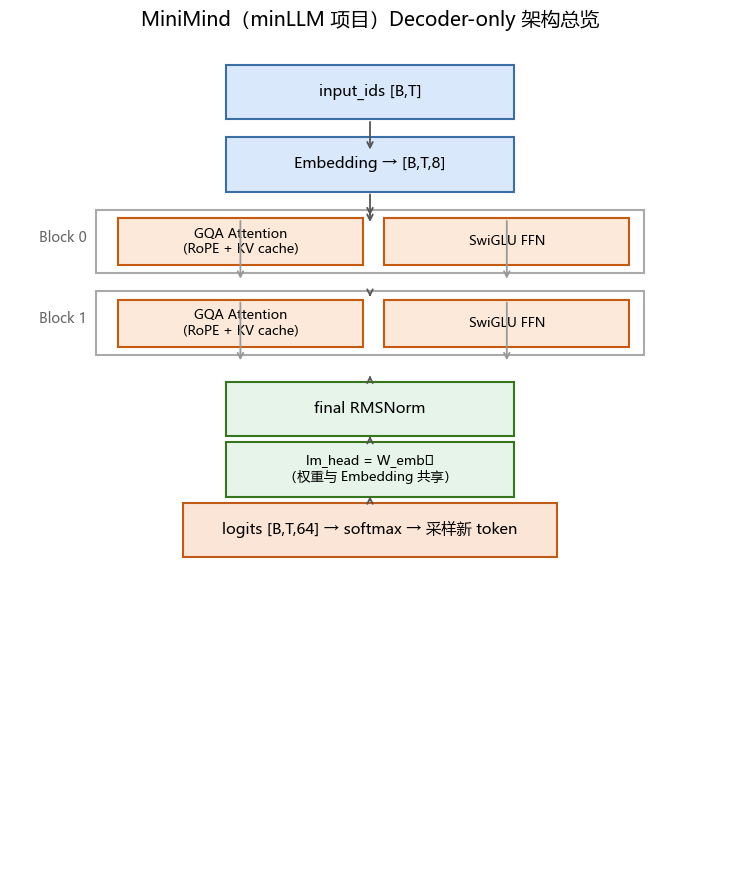

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(7.5, 9))
ax.set_xlim(0, 10); ax.set_ylim(0, 14); ax.axis('off')

def box(x, y, w, h, t, fc='#E8F0FE', ec='#3B6EA5', fs=11):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.5))
    ax.text(x + w / 2, y + h / 2, t, ha='center', va='center', fontsize=fs)

def ar(x1, y1, x2, y2, color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.3))

y = 12.6; box(3, y, 4, 0.9, 'input_ids [B,T]', '#DAE8FC')
ar(5, y, 5, y - 0.55)
y -= 1.2; box(3, y, 4, 0.9, 'Embedding → [B,T,8]', '#DAE8FC')
ar(5, y, 5, y - 0.55)
# Block x2
for lyr in ['Block 0', 'Block 1']:
    y -= 1.35
    box(1.2, y, 7.6, 1.05, '', '#FFFFFF', '#AAAAAA', 0)
    box(1.5, y + 0.13, 3.4, 0.78, 'GQA Attention\n(RoPE + KV cache)', '#FDE9D9', '#C55A11', 9.5)
    box(5.2, y + 0.13, 3.4, 0.78, 'SwiGLU FFN', '#FDE9D9', '#C55A11', 9.5)
    ax.text(0.4, y + 0.52, lyr, fontsize=10, color='#666')
    ar(5, y + 1.05, 5, y + 0.91)
    ar(3.2, y + 0.91, 3.2, y - 0.14, '#999')   # 残差旁路示意
    ar(6.9, y + 0.91, 6.9, y - 0.14, '#999')
y -= 1.35
box(3, y, 4, 0.9, 'final RMSNorm', '#E6F4EA', '#38761D')
ar(5, y + 0.9, 5, y + 1.05)
y -= 1.0
box(3, y, 4, 0.9, 'lm_head = W_embᵀ\n（权重与 Embedding 共享）', '#E6F4EA', '#38761D', 9.5)
ar(5, y + 0.9, 5, y + 1.05)
y -= 1.0
box(2.4, y, 5.2, 0.9, 'logits [B,T,64] → softmax → 采样新 token', '#FBE5D6', '#BF5B17')
ar(5, y + 0.9, 5, y + 1.05)
ax.set_title('MiniMind（minLLM 项目）Decoder-only 架构总览', fontsize=14)
plt.tight_layout(); plt.show()


## 模块 1：RMSNorm（源码 L50-60）

MiniMind 不用 LayerNorm，用 **RMSNorm**（LLaMA 系标准）：不做均值中心化、没有 β 偏置，
只按 RMS 缩放后乘可学习 γ：

$$\mathrm{RMSNorm}(x)=\hat{x}\cdot\gamma,\qquad \hat{x}=\frac{x}{\sqrt{\mathrm{mean}(x^2)+\varepsilon}}$$

更省算力（不做均值），反传更简单；EPS 用 1e-6。第 5 讲已手搓过，这里直接复用并打印形状。


In [3]:
class RMSNorm:
    def __init__(self, dim, eps=cfg['rms_norm_eps']):
        self.gamma = np.ones(dim)                 # 可学习缩放，初始全 1
        self.eps = eps
    def __call__(self, x):
        rms = np.sqrt(np.mean(x ** 2, axis=-1, keepdims=True) + self.eps)
        return x / rms * self.gamma

x_in = np.random.randn(B, T, cfg['hidden_size'])
out = RMSNorm(cfg['hidden_size'])(x_in)
print('RMSNorm  :', x_in.shape, '->', out.shape, '| 每行 RMS≈1：', np.round(np.sqrt(np.mean(out**2, -1))[0, :3], 4))


RMSNorm  : (2, 6, 8) -> (2, 6, 8) | 每行 RMS≈1： [1. 1. 1.]


## 模块 2：RoPE 旋转位置编码（源码 L62-84）

与第 3 讲相同：频率表 `freqs_cis`（`rope_theta=64` 时旋转周期更密，小模型够用）+
`apply_rotary_pos_emb`（把 query/key 的每对维度按位置旋转）。只对 **Q、K** 旋转，V 不旋转。

**decode 场景只旋转新增的 1 个位置的 Q/K**，历史上已旋转的 K 直接存进 KV 缓存，
这是增量解码高效的关键之一。


In [4]:
def precompute_freqs_cis(dim, max_len, theta):
    """频率表：freq_cis[i] = e^{i·θ_i}（复数形式，θ_i 按维度递减）。"""
    freqs = 1.0 / (theta ** (np.arange(0, dim, 2) / dim))   # [dim/2]
    t = np.arange(max_len)
    angles = np.outer(t, freqs)                              # [max_len, dim/2]
    return np.exp(1j * angles)                               # [max_len, dim/2]

def apply_rotary(x, freqs_cis):
    """旋转 x：[..., dim] 每对 (x0,x1) -> (x0·cosθ − x1·sinθ, x0·sinθ + x1·cosθ)。
    复数法：拆成 halves 组合复向量乘以 e^{iθ} 再拼回（与源码 rotate_half 等价）。"""
    d = x.shape[-1]; half = d // 2
    xr = x[..., :half] + 1j * x[..., half:]                  # 复向量 [..., half]
    rot = xr * freqs_cis                                     # 乘以旋转因子
    return np.concatenate([rot.real, rot.imag], axis=-1)

freqs_cis = precompute_freqs_cis(cfg['head_dim'], cfg['max_position_embeddings'], cfg['rope_theta'])
print('freqs_cis 形状', freqs_cis.shape, '| 频率（弧度）：', np.round(np.angle(freqs_cis[0, :4]), 3))
q_sample = np.random.randn(B, 1, cfg['num_attention_heads'], cfg['head_dim'])
q_rot = apply_rotary(q_sample, freqs_cis[0])
print('Q 第 1 位置旋转:', q_sample.shape, '->', q_rot.shape)


freqs_cis 形状 (64, 1) | 频率（弧度）： [0.]
Q 第 1 位置旋转: (2, 1, 4, 2) -> (2, 1, 4, 2)


## 模块 3：GQA 注意力 + KV 缓存（源码 L91-134）—— 本讲重点

MiniMind 的 `Attention` 是 **GQA**：`num_attention_heads=4, num_key_value_heads=2`，
`n_rep = 4//2 = 2`，每个 KV 头服务 2 个 Q 头（`repeat_kv` 复制后拼接）。

**KV 缓存**（增量解码的关键，源码 `past_key_value`）：
- **prefill（预填充）**：第一次前向，输入整个提示词，`cache=None`，算出所有位置的 K/V 存进缓存
- **decode（逐 token 生成）**：每次只输入 **1 个新 token**，K/V 拼接在缓存的后面
  → 注意力只算新 Q 与 全部 K 的点积（矩阵从 [T,T] 变成 [1, T]），避免了重复计算历史 token 的 K/V

流程：投影 q/k/v → 拆头 → **新 K/V 与缓存拼接** → 只旋转新位置的 Q/K → repeat_kv → 点积/softmax/加权求和 → 合并投影。


In [5]:
def repeat_kv(x, n_rep):
    """每个 KV 头复制 n_rep 份：[B, kv_h, T, dk] -> [B, kv_h*n_rep, T, dk]。"""
    return np.repeat(x, n_rep, axis=1)

class GQAAttention:
    def __init__(self, cfg, seed=1):
        d, h, kv_h, hd = cfg['hidden_size'], cfg['num_attention_heads'], cfg['num_key_value_heads'], cfg['head_dim']
        rng = np.random.default_rng(seed)
        def w(shape): return rng.standard_normal(shape) * 0.03
        self.Wq = w((d, h * hd)); self.Wk = w((d, kv_h * hd)); self.Wv = w((d, kv_h * hd))
        self.Wo = w((h * hd, d))
        self.h, self.kv_h, self.hd, self.n_rep = h, kv_h, hd, h // kv_h
    def forward(self, x, freqs_cis, mask=None, cache=None, positions=0):
        """x [B, T_cur, d]；cache=(k,v)；positions: 当前 x 的起始位置（预填充=0）。返回 out, (k, v)。"""
        B, T_cur, d = x.shape
        q = x @ self.Wq                       # [B, T_cur, h*hd]
        k = x @ self.Wk                       # [B, T_cur, kv_h*hd]
        v = x @ self.Wv
        def split(t, n_h):
            return t.reshape(B, T_cur, n_h, self.hd).transpose(0, 2, 1, 3)  # [B,n_h,T_cur,hd]
        q, k, v = split(q, self.h), split(k, self.kv_h), split(v, self.kv_h)
        # 只旋转"本步新增"位置的 Q/K（RoPE 后 K 进缓存）
        pos = np.arange(positions, positions + T_cur)
        q = apply_rotary(q, freqs_cis[pos]); k = apply_rotary(k, freqs_cis[pos])
        if cache is not None:                 # 增量：拼接历史 KV
            k = np.concatenate([cache[0], k], axis=2)
            v = np.concatenate([cache[1], v], axis=2)
        k_r, v_r = repeat_kv(k, self.n_rep), repeat_kv(v, self.n_rep)   # [B, h, T_all, hd]
        scores = np.matmul(q, k_r.swapaxes(-1, -2)) / math.sqrt(self.hd)  # [B,h,T_cur,T_all]
        if mask is not None: scores = np.where(mask, -np.inf, scores)
        attn = np.exp(scores - np.max(scores, -1, keepdims=True))
        attn = attn / attn.sum(-1, keepdims=True)                        # [B,h,T_cur,T_all]
        o = np.matmul(attn, v_r)                                         # [B,h,T_cur,hd]
        o = o.transpose(0, 2, 1, 3).reshape(B, T_cur, self.h * self.hd)
        return o @ self.Wo, (k, v)

# ---- 预填充 + 张量形状打印 ----
attn = GQAAttention(cfg)
emb_in = np.random.randn(B, T, cfg['hidden_size'])
o_prefill, (k_cache, v_cache) = attn.forward(emb_in, freqs_cis, positions=0)
print('prefill out:', o_prefill.shape, '| K 缓存:', k_cache.shape, '(B, 2 KV 头, 6 位置, dk=2)')
# ---- 增量解码前向（只算第 6 个新 token） ----
x_new = np.random.randn(B, 1, cfg['hidden_size'])
o_dec, (k_new, v_new) = attn.forward(x_new, freqs_cis, positions=6, cache=(k_cache, v_cache))
print('decode  out:', o_dec.shape, '| K 变长到', k_new.shape[2], '个位置（拼接成功）')


prefill out: (2, 6, 8) | K 缓存: (2, 2, 6, 2) (B, 2 KV 头, 6 位置, dk=2)
decode  out: (2, 1, 8) | K 变长到 7 个位置（拼接成功）


### KV 缓存的数值等价验证

**关键性质**：增量解码（一次 1 个 token，用缓存）与全量解码（每次把整个序列重新算一遍）
得到的 GQA 输出必须**逐位相同**——下面验证第 3 步 decode 的输出。


In [6]:
def causal_mask(nq, nk):
    """因果掩码：query 全局位置 = nk-nq+i，屏蔽 j > 自己全局位置（未来 key）。
    全量时 nq=nk=8 退化为上三角；增量 decode 时 nk=缓存长度 > nq。"""
    i = np.arange(nq)[:, None]; j = np.arange(nk)[None, :]
    return (nk - nq + i) < j

seq = np.random.randn(B, 8, cfg['hidden_size'])     # 一次性准备 8 个位置的输入
# 全量：8 个位置一次前向，带因果掩码
o_full, _ = attn.forward(seq, freqs_cis, mask=causal_mask(8, 8), positions=0)
# 增量：先 prefill 3 个位置，再逐步 decode（每步 mask 只允许看历史 + 当前）
o_inc = []; kc = vc = None
for p in range(0, 8, 3):                        # 块 0: [0,3)、块 3: [3,6)、块 6: [6,8)
    nq = 3 if p < 6 else 2
    o_part, (kc, vc) = attn.forward(seq[:, p:p+nq], freqs_cis, positions=p,
                                    mask=causal_mask(nq, p + nq),
                                    cache=(kc, vc) if kc is not None else None)
    o_inc.append(o_part)
o_inc = np.concatenate(o_inc, axis=1)
err = np.abs(o_inc - o_full).max()
assert err < 1e-10, err
print(f'KV 缓存分块 vs 全量前向（因果语义）:  max abs err = {err:.3e}   ->  PASS（增量与全量严格等价）')


KV 缓存分块 vs 全量前向（因果语义）:  max abs err = 8.674e-19   ->  PASS（增量与全量严格等价）


## 模块 4：SwiGLU FFN（源码 L136-146）

与第 4 讲相同：`down(SiLU(gate(x)) ⊙ up(x))`，`intermediate_size=16`。
MiniMind 源码里就是三个线性层 `gate_proj / up_proj / down_proj` 加 `F.silu`。


In [7]:
class SwiGLU:
    def __init__(self, cfg, seed=2):
        d, itm = cfg['hidden_size'], cfg['intermediate_size']
        rng = np.random.default_rng(seed)
        self.Wg = rng.standard_normal((d, itm)) * 0.03     # gate 门控投影
        self.Wu = rng.standard_normal((d, itm)) * 0.03     # up 内容投影
        self.Wd = rng.standard_normal((itm, d)) * 0.03     # down 降维投影
    def __call__(self, x):
        silu = lambda z: z / (1 + np.exp(-z))              # SiLU(x) = x·σ(x)
        return (silu(x @ self.Wg) * (x @ self.Wu)) @ self.Wd

ffn = SwiGLU(cfg)
print('SwiGLU FFN:', emb_in.shape, '->', ffn(emb_in).shape)


SwiGLU FFN: (2, 6, 8) -> (2, 6, 8)


## 模块 5：MiniMindBlock（源码 L183-199）

每一层/块 = **Pre-LN** 结构：`RMSNorm → 注意力 → 残差`，`RMSNorm → FFN → 残差`。

> Pre-LN（先归一化再子层）是现代 LLM 与原始 Transformer（Post-LN）的最大结构差别：
> 梯度链路绕过归一化，深层训练更稳。第 5 讲对比过。


In [8]:
class MiniMindBlock:
    def __init__(self, cfg, layer_id):
        self.norm1 = RMSNorm(cfg['hidden_size'])
        self.attn = GQAAttention(cfg, seed=3 + layer_id)
        self.norm2 = RMSNorm(cfg['hidden_size'])
        self.ffn = SwiGLU(cfg, seed=5 + layer_id)
    def forward(self, h, freqs_cis, mask=None, cache=None, positions=0):
        # 子层 1：RMSNorm → GQA 注意力 → 残差
        a, kvcache = self.attn.forward(self.norm1(h), freqs_cis, mask, cache, positions)
        h = h + a
        # 子层 2：RMSNorm → SwiGLU → 残差
        h = h + self.ffn(self.norm2(h))
        return h, kvcache

block = MiniMindBlock(cfg, 0)
o_b, _ = block.forward(emb_in, freqs_cis, positions=0)
print('MiniMindBlock:', emb_in.shape, '->', o_b.shape)


MiniMindBlock: (2, 6, 8) -> (2, 6, 8)


## 模块 6：完整模型 + 权重共享 + 损失（源码 L201-237 / L239-260）

`MiniMindModel`: Embedding → N 层 Block → final RMSNorm；
`MiniMindForCausalLM`: 输出侧 `lm_head(x) = x @ W_embᵀ`（**共享矩阵**）→ logits [B,T,V]。
损失：标签右移一位，`labels[t] = ids[t+1]`、最后一位忽略（`ignore_index=-100`）——即"预测下一个 token"。


In [9]:
class MiniMindForCausalLM:
    def __init__(self, cfg, seed=7):
        rng = np.random.default_rng(seed)
        self.W_emb = rng.standard_normal((cfg['vocab_size'], cfg['hidden_size'])) * 0.05
        self.blocks = [MiniMindBlock(cfg, i) for i in range(cfg['num_hidden_layers'])]
        self.final_norm = RMSNorm(cfg['hidden_size'])
    def forward(self, ids, mask=None, caches=None, positions=0):
        """ids [B,T]；caches: 每层 (k,v) 列表（None=prefill）。返回 logits [B,T,V] 与逐层缓存。"""
        B, T_ = ids.shape
        h = self.W_emb[ids]                              # [B,T,8] 查表（Embedding）
        new_caches = []
        for i, blk in enumerate(self.blocks):
            prev = caches[i] if caches is not None else None
            h, kvc = blk.forward(h, freqs_cis, mask, prev, positions)
            new_caches.append(kvc)
        h = self.final_norm(h)
        logits = h @ self.W_emb.T                        # 与 Embedding 共享（tie）
        return logits, new_caches

def cross_entropy_last(logits, ids):
    """next-token 预测损失：labels[t] = ids[t+1]，末位忽略。返回 (loss, 正确率)。"""
    logits = logits[:, :-1].reshape(-1, logits.shape[-1])          # 去掉最后一个位置的预测
    labels = ids[:, 1:].reshape(-1)                                # 标签右移一位
    logits = logits - np.max(logits, -1, keepdims=True)
    p = np.exp(logits); p /= p.sum(-1, keepdims=True)
    loss = -np.mean(np.log(p[np.arange(labels.size), labels] + 1e-12))
    acc = np.mean(p.argmax(-1) == labels)
    return loss, acc

ids = np.random.randint(0, cfg['vocab_size'], (B, T))
model = MiniMindForCausalLM(cfg)
logits, _ = model.forward(ids)
loss, acc = cross_entropy_last(logits, ids)
print('logits:', logits.shape, '| loss =', round(loss, 4), '| 随机初始正确率 ≈', round(acc, 3), '(≈1/64 正常)')
print('权重共享验证：lm_head 就是 W_emb 转置 → 共享参数量 = 词表维(64×8) 不翻倍')


logits: (2, 6, 64) | loss = 4.1309 | 随机初始正确率 ≈ 0.1 (≈1/64 正常)
权重共享验证：lm_head 就是 W_emb 转置 → 共享参数量 = 词表维(64×8) 不翻倍


## 模块 7：自回归生成（源码 L262-293 `generate`）

MiniMind 的 generate 参数：`temperature=0.85, top_k=50, top_p=0.85, repetition_penalty=1.0, do_sample=True`。
流程每步：新 Q 查全部 KV 缓存 → logits 最后一个位置 → 温度缩放 → top-k/top-p 截断 → 多项式采样 → 新 token 追加。

下面实现一个"玩具版生成"，并验证**增量解码（全程 KV 缓存）与全量重算的自回归输出一致**。


In [10]:
def top_k_top_p_filtering(probs, top_k=0, top_p=1.0):
    """top-k 截断：保留概率最大的 k 个；top-p：保留累积概率到 p 的最小集合（与 HF 相同规则）。"""
    if top_k > 0:
        kth = np.sort(probs, -1)[:, -top_k][:, None]
        probs = np.where(probs < kth, 0.0, probs)          # 其余置 0
    if top_p < 1.0:
        order = np.argsort(-probs, axis=-1)                # 概率降序排列
        sorted_probs = np.take_along_axis(probs, order, -1)
        cum = np.cumsum(sorted_probs, -1)
        keep_sorted = (cum - sorted_probs) <= top_p        # 保留"还没超过 p"的（含引起超过的那个）
        keep = np.zeros_like(keep_sorted)
        np.put_along_axis(keep, order, keep_sorted, axis=-1)   # 放回原顺序
        probs = np.where(keep, probs, 0.0)
    return probs / probs.sum(-1, keepdims=True)

def sample_token(logits, temperature=1.0, top_k=0, top_p=1.0, rng=np.random.default_rng(0)):
    """从 logits [B, V] 采样 1 个 token [B]。"""
    logits = logits / max(temperature, 1e-8)
    logits = logits - np.max(logits, -1, keepdims=True)
    probs = np.exp(logits); probs /= probs.sum(-1, keepdims=True)
    probs = top_k_top_p_filtering(probs, top_k, top_p)
    cdf = np.cumsum(probs, -1)
    return (cdf < rng.random((logits.shape[0], 1))).sum(-1)

def generate(model, prompt_ids, max_new=8, temperature=0.8, top_k=5, top_p=0.9, use_cache=True, seed=0):
    """自回归生成：返回生成的 token 序列 [B, max_new]（含增量/全量两种模式的等价对照）。"""
    rng = np.random.default_rng(seed)
    seq = prompt_ids.copy(); caches = None; generated = []
    for step in range(max_new):
        if use_cache:
            logits, caches = model.forward(seq[:, -1:], caches=caches, positions=seq.shape[1] - 1)
        else:
            # 全量重算：每次把整个序列重新前向（带因果掩码，与增量语义一致）
            logits, _ = model.forward(seq, mask=causal_mask(seq.shape[1], seq.shape[1]), caches=None, positions=0)
            caches = None
        nxt = sample_token(logits[:, -1], temperature, top_k, top_p, rng)
        seq = np.concatenate([seq, nxt[:, None]], axis=1)
        generated.append(nxt)
    return np.stack(generated, axis=1)

prompt = np.array([[5, 12, 3]], dtype=np.int64)
g_inc = generate(model, prompt, use_cache=True, seed=1)
g_full = generate(model, prompt, use_cache=False, seed=1)
same = np.array_equal(g_inc, g_full)
print('增量生成:', g_inc[0].tolist())
print('全量生成:', g_full[0].tolist())
print('两者一致:', same, ' -> ', 'PASS' if same else 'FAIL')
print('（同一随机种子下，KV 缓存增量解码与全量重算输出严格相同——缓存只省算力、不改结果）')


增量生成: [27, 57, 15, 57, 27, 15, 57, 52]
全量生成: [27, 57, 15, 57, 27, 15, 57, 52]
两者一致: True  ->  PASS
（同一随机种子下，KV 缓存增量解码与全量重算输出严格相同——缓存只省算力、不改结果）


## 模块 8：MiniMind 训练流水线（trainer/ 目录）

MiniMind 的完整训练 = 预训练 + SFT + DPO + PPO/GRPO + 蒸馏 + LoRA：

| 阶段 | 脚本 | 数据 | 目标 |
|---|---|---|---|
| 预训练 | `train_pretrain.py` | 海量纯文本 | next-token 预测，学语言能力 |
| 指令微调 SFT | `train_full_sft.py` / `train_lora.py` | 指令-回答 | 学会"听指令" |
| 人类对齐 DPO | `train_dpo.py` | 偏好对 (好,坏) | 直接偏好优化，学"说什么" |
| 强化学习 | `train_ppo.py` / `train_grpo.py` | 奖励模型/规则 | 进一步提升有用性 |
| 蒸馏 | `train_distillation.py` | 教师输出 | 小模型学大模型 |

主线：**预训练 → 全参/LoRA 微调 → DPO/PPO 对齐**（与 GPT 系列一致）。
本讲的小模型用同一套前向/损失函数即可跑 `train_pretrain.py` 的逻辑（只是数据换成随机整数）。


## 模块 9：MiniMind vs 原始 Transformer vs LLaMA

| 组件 | 原始 Transformer (2017) | LLaMA (2022) | MiniMind (minLLM) |
|---|---|---|---|
| 结构 | Encoder-Decoder | Decoder-only | Decoder-only |
| 注意力 | MHA | GQA（70B） / MQA（更小） | **GQA** 8 Q / 4 KV |
| 归一化 | LayerNorm + Post-LN | RMSNorm + Pre-LN | RMSNorm + Pre-LN（eps=1e-6） |
| 位置编码 | 正弦 | RoPE（theta=1e4） | **RoPE**（theta=1e6） |
| 激活 | ReLU | SwiGLU | **SwiGLU**（silu） |
| 权重共享 | 无 | 部分模型 | **tie_word_embeddings=True** |
| 采样 | greedy | temperature/top-k/top-p | 同 LLaMA |

**本讲知识对照 1-8 讲**：RMSNorm（第 5 讲）→ RoPE（第 3 讲）→ GQA/KV 缓存（第 8 讲）→ SwiGLU（第 4 讲）→ Pre-LN Block（第 6 讲）→ 输出/采样（第 7 讲）→ 自注意力（第 1、2 讲）。


## 总 结

- MiniMind = **LLaMA 风格 Decoder-only**：`Embedding → 8×Block → RMSNorm → 共享 lm_head`。
- 单块 = **Pre-LN**：`RMSNorm→GQA(带RoPE)→残差` + `RMSNorm→SwiGLU→残差`。
- **KV 缓存**让增量生成从 $O(T^2)$ 降到 $O(T)$（与全量重算严格等价，已数值验证）。
- **推理管线**：温度 → top-k → top-p → 采样；训练管线：预训练 → SFT → DPO/PPO → 蒸馏/LoRA。
- 现在回到 `model/model_minimind.py`（293 行），对照本讲每个模块的行号，你可以完整读懂这个真实 LLM 项目。
